In [7]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

def plot_pm_ra_dec(fits_file, cluster_name):
    data = fits.open(fits_file)[1].data

    pmRA  = data["GAIAEDR3_PMRA"]
    pmDec = data["GAIAEDR3_PMDEC"]

    pmRA_err  = data["GAIAEDR3_PMRA_ERROR"]
    pmDec_err = data["GAIAEDR3_PMDEC_ERROR"]

    plx = data["GAIAEDR3_PARALLAX_CORRECTED"]
    plx_err = data["GAIAEDR3_PARALLAX_ERROR"]

    hbscan2 = data["HDBscan_cluster"] == -2
    members = data["MEMBOOL"] == 1  
    non_members = data["MEMBOOL"] == 0

    fig, (RA, DEC) = plt.subplots(1, 2, figsize=(12,6))

    RA.plot(pmRA[non_members], plx[non_members], 'o', markersize=3, alpha=0.4, label='Non-members', color='tab:blue')
    RA.plot(pmRA[members], plx[members], 'o', markersize=3, alpha=0.7, color='tab:orange', label='Members')
    RA.errorbar(pmRA[hbscan2], plx[hbscan2], xerr=pmRA_err[hbscan2], yerr=plx_err[hbscan2],
                fmt='o', markersize=3, alpha=0.5, color='tab:green', label='HDBscan_cluster=-2')

    RA.set_xlabel("PMRA (mas/yr)")
    RA.set_ylabel("Parallax (mas)")
    RA.set_title(f"{cluster_name}: Parallax vs RA")
    RA.legend()

    # Plot Parallax vs PMDec
    DEC.plot(pmDec[non_members], plx[non_members], 'o', markersize=3, alpha=0.4, label='Non-members', color='tab:blue')
    DEC.plot(pmDec[members], plx[members], 'o', markersize=3, alpha=0.7, color='tab:orange', label='Members')
    DEC.errorbar(pmDec[hbscan2], plx[hbscan2], xerr=pmDec_err[hbscan2], yerr=plx_err[hbscan2],
                 fmt='o', markersize=3, alpha=0.5, color='tab:green', label='HDBscan_cluster=-2')

    DEC.set_xlabel("PMDec (mas/yr)")
    DEC.set_ylabel("Parallax (mas)")
    DEC.set_title(f"{cluster_name}: Parallax vs DEC")
    DEC.legend()

    plt.tight_layout()
    plt.show()
    

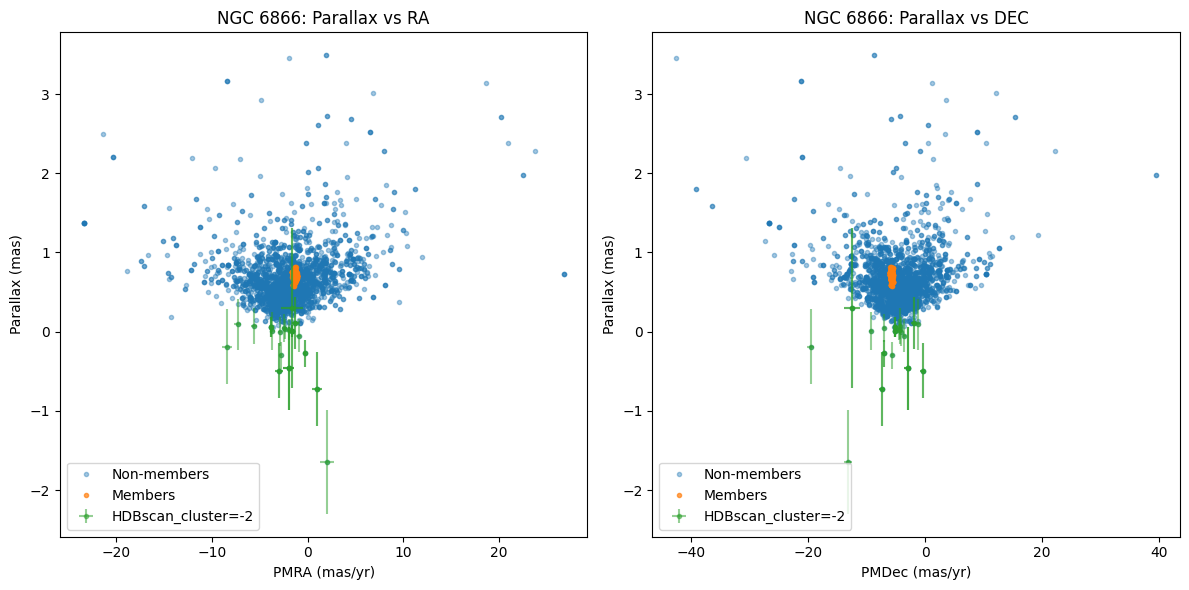

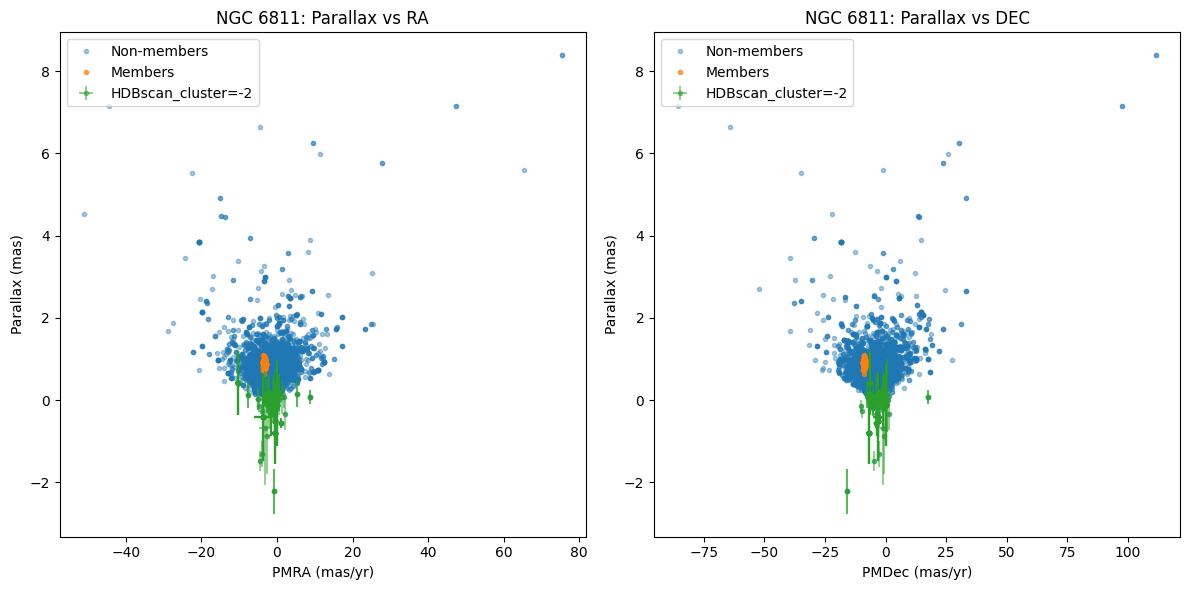

In [13]:
plot_pm_ra_dec("rcat_ngc6866_v0.fits", "NGC 6866")
plot_pm_ra_dec("rcat_ngc6811_v0.fits", "NGC 6811")